# Notebook 1 — Base Model Experiments

This notebook always starts from the **original pretrained model** such as `distilbert-base-uncased`.

Use it when you want to test different:

- dataset sizes
- batch sizes
- learning rates
- epochs
- max token length
- early stopping settings

Every run is saved in a new version folder.  
The notebook compares the current run with the saved **best base-model experiment** using validation `f1_macro`.  
If the new run is better, it updates the `best_model` folder.

In [ ]:
!pip install -q datasets==2.18.0 transformers accelerate scikit-learn seaborn pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


## 1. Imports and Google Drive

The model outputs will be saved in Google Drive, so Colab restarts will not delete them.

In [ ]:
import os
import json
import random
import shutil
from datetime import datetime

import numpy as np
import pandas as pd
import torch

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline
)

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Experiment configuration

Change the values in this cell to run a new experiment.

Important idea:

- `MAX_PER_CLASS_TRAIN = 50000` means the training set will use up to 50,000 reviews from each class.
- Since there are 3 classes, the training size becomes about 150,000 reviews.
- If you increase `MAX_PER_CLASS_TRAIN`, you train on more data.
- `EARLY_STOPPING_PATIENCE = 1` means training stops if validation F1 does not improve after one evaluation.

In [ ]:
# =========================
# Project paths
# =========================

ROOT_DIR = "/content/drive/MyDrive/DataMining_Project"
DATA_PATH = f"{ROOT_DIR}/clothing_reviews.parquet"

# Folder for experiments that start from the original pretrained model
EXPERIMENT_DIR = f"{ROOT_DIR}/01_BaseModel_Experiments"
VERSIONS_DIR = f"{EXPERIMENT_DIR}/versions"
BEST_MODEL_DIR = f"{EXPERIMENT_DIR}/best_model"
LOG_PATH = f"{EXPERIMENT_DIR}/experiments_log.csv"
BEST_METRICS_PATH = f"{EXPERIMENT_DIR}/best_metrics.json"

# Fixed evaluation sets make comparison fair across different training sizes
FIXED_EVAL_DIR = f"{ROOT_DIR}/fixed_evaluation_sets"
VAL_PATH = f"{FIXED_EVAL_DIR}/fixed_validation.parquet"
TEST_PATH = f"{FIXED_EVAL_DIR}/fixed_test.parquet"

os.makedirs(VERSIONS_DIR, exist_ok=True)
os.makedirs(FIXED_EVAL_DIR, exist_ok=True)

# =========================
# Main experiment parameters
# =========================

SEED = 42

BASE_MODEL_NAME = "distilbert-base-uncased"
# BASE_MODEL_NAME = "bert-base-uncased"  # slower, but full BERT

MAX_PER_CLASS_TRAIN = 100000       # change this to test dataset size
FIXED_EVAL_PER_CLASS = 5000       # fixed validation and test size per class

MAX_LENGTH = 256                  # try 128 or 256
LEARNING_RATE = 2e-5              # try 2e-5, 3e-5, 1e-5
NUM_TRAIN_EPOCHS = 3              # early stopping may stop before this
TRAIN_BATCH_SIZE = 16             # reduce to 8 if CUDA memory error
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01

# Early stopping
USE_EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 1
EARLY_STOPPING_THRESHOLD = 0.0

# Optional: re-evaluate old best model every run.
# False is faster because it trusts best_metrics.json.
REEVALUATE_EXISTING_BEST = False

# Create a unique run name
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_SHORT = BASE_MODEL_NAME.replace("/", "_")
RUN_NAME = (
    f"{RUN_ID}_{MODEL_SHORT}"
    f"_perclass{MAX_PER_CLASS_TRAIN}"
    f"_lr{LEARNING_RATE}"
    f"_ep{NUM_TRAIN_EPOCHS}"
    f"_maxlen{MAX_LENGTH}"
)

RUN_DIR = f"{VERSIONS_DIR}/{RUN_NAME}"
CHECKPOINT_DIR = f"{RUN_DIR}/checkpoints"
CURRENT_MODEL_DIR = f"{RUN_DIR}/final_model"

os.makedirs(RUN_DIR, exist_ok=True)

print("Run folder:")
print(RUN_DIR)

Run folder:
/content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/versions/20260427_171438_distilbert-base-uncased_perclass100000_lr2e-05_ep3_maxlen256


## 3. Utility functions

These functions keep the notebook organized.

- `set_seed()` makes results more reproducible.
- `create_training_args()` supports both newer and older Transformers versions.
- `create_trainer()` also supports both `processing_class=tokenizer` and the older `tokenizer=tokenizer`.
- `update_best_model_if_needed()` updates the best model only when validation F1 improves.

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    print("GPU available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU name:", torch.cuda.get_device_name(0))


def save_json(path, obj):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def append_experiment_log(log_path, row):
    row_df = pd.DataFrame([row])

    if os.path.exists(log_path):
        old_df = pd.read_csv(log_path)
        out_df = pd.concat([old_df, row_df], ignore_index=True)
    else:
        out_df = row_df

    out_df.to_csv(log_path, index=False)


def create_training_args():
    common_args = dict(
        output_dir=CHECKPOINT_DIR,
        save_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    try:
        return TrainingArguments(eval_strategy="epoch", **common_args)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", **common_args)


def create_trainer(model, training_args, tokenized_datasets, tokenizer, data_collator, compute_metrics, callbacks=None):
    callbacks = callbacks or []

    try:
        return Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_datasets["train"],
            eval_dataset=tokenized_datasets["validation"],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=callbacks
        )
    except TypeError:
        return Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_datasets["train"],
            eval_dataset=tokenized_datasets["validation"],
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=callbacks
        )


def model_folder_exists(path):
    return os.path.exists(os.path.join(path, "config.json"))


def evaluate_saved_model(model_path, tokenized_eval_dataset, tokenizer, training_args, data_collator, compute_metrics):
    saved_model = AutoModelForSequenceClassification.from_pretrained(model_path)

    try:
        temp_trainer = Trainer(
            model=saved_model,
            args=training_args,
            eval_dataset=tokenized_eval_dataset,
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics
        )
    except TypeError:
        temp_trainer = Trainer(
            model=saved_model,
            args=training_args,
            eval_dataset=tokenized_eval_dataset,
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics
        )

    results = temp_trainer.evaluate()

    del saved_model
    del temp_trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results


def update_best_model_if_needed(current_f1, current_metrics, trainer, tokenizer, run_info):
    old_best_f1 = None

    if os.path.exists(BEST_METRICS_PATH):
        best_info = load_json(BEST_METRICS_PATH)
        old_best_f1 = best_info.get("validation_f1_macro")

    print("Previous best validation F1:", old_best_f1)
    print("Current validation F1:", current_f1)

    is_better = old_best_f1 is None or current_f1 > old_best_f1

    if is_better:
        if os.path.exists(BEST_MODEL_DIR):
            shutil.rmtree(BEST_MODEL_DIR)

        trainer.save_model(BEST_MODEL_DIR)
        tokenizer.save_pretrained(BEST_MODEL_DIR)

        best_info = {
            **run_info,
            "validation_f1_macro": float(current_f1),
            "validation_metrics": current_metrics,
            "best_model_dir": BEST_MODEL_DIR,
            "updated_at": datetime.now().isoformat()
        }

        save_json(BEST_METRICS_PATH, best_info)

        print("New best model saved:")
        print(BEST_MODEL_DIR)
    else:
        print("Current model did not beat the old best model.")

    return is_better


set_seed(SEED)

GPU available: True
GPU name: Tesla T4


## 4. Load and clean the dataset

This notebook expects your cleaned dataset here:

`/content/drive/MyDrive/DataMining_Project/clothing_reviews.parquet`

Expected columns:

- `rating`
- `bert_input`
- `label`

In [ ]:
df = pd.read_parquet(DATA_PATH)

df = df[["rating", "bert_input", "label"]].copy()
df = df.dropna(subset=["bert_input", "label"]).copy()

df["bert_input"] = df["bert_input"].astype(str).str.strip()
df = df[df["bert_input"].str.len() > 0].copy()

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"]).copy()

df["label"] = df["label"].astype(int)
df = df[df["label"].isin([0, 1, 2])].copy()

df = df.reset_index(drop=True)
df["row_id"] = df.index

label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print("Rows:", len(df))
print(df["label"].map(label_names).value_counts())
df.head()

Rows: 2500000
label
positive    1990262
negative     282297
neutral      227441
Name: count, dtype: int64


,rating,bert_input,label,row_id
0,3.0,"Nice shirts, run very small I am 5’7” and weig...",1,0
1,5.0,Love it This is a great wardrobe staple. It is...,2,1
2,4.0,Good for fall It is a good fit for normal wear...,2,2
3,4.0,this shirt fit very nice and seems to be well ...,2,3
4,5.0,"Fits well, washes nice. This crop top sports b...",2,4


## 5. Create fixed validation and test sets

This is important for fair comparison.

If every experiment uses a different validation set, then the comparison is not clean.  
So this notebook creates one fixed validation set and one fixed test set, then reuses them for all future runs.

If you want to recreate them, delete the files in:

`DataMining_Project/fixed_evaluation_sets/`

In [ ]:
def create_fixed_eval_sets(df):
    if os.path.exists(VAL_PATH) and os.path.exists(TEST_PATH):
        print("Loading existing fixed validation and test sets.")
        val_df = pd.read_parquet(VAL_PATH)
        test_df = pd.read_parquet(TEST_PATH)
        return val_df, test_df

    print("Creating fixed validation and test sets for the first time.")

    val_parts = []
    test_parts = []

    for label in sorted(df["label"].unique()):
        class_df = df[df["label"] == label]

        needed = FIXED_EVAL_PER_CLASS * 2
        if len(class_df) < needed:
            raise ValueError(f"Not enough rows for label {label}. Need at least {needed}.")

        sampled = class_df.sample(n=needed, random_state=SEED)

        val_part = sampled.iloc[:FIXED_EVAL_PER_CLASS]
        test_part = sampled.iloc[FIXED_EVAL_PER_CLASS:]

        val_parts.append(val_part)
        test_parts.append(test_part)

    val_df = pd.concat(val_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
    test_df = pd.concat(test_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

    val_df.to_parquet(VAL_PATH, index=False)
    test_df.to_parquet(TEST_PATH, index=False)

    print("Saved fixed validation set:", VAL_PATH)
    print("Saved fixed test set:", TEST_PATH)

    return val_df, test_df


val_df, test_df = create_fixed_eval_sets(df)

eval_ids = set(val_df["row_id"].tolist()) | set(test_df["row_id"].tolist())
train_pool_df = df[~df["row_id"].isin(eval_ids)].copy()

print("Train pool:", train_pool_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Creating fixed validation and test sets for the first time.
Saved fixed validation set: /content/drive/MyDrive/DataMining_Project/fixed_evaluation_sets/fixed_validation.parquet
Saved fixed test set: /content/drive/MyDrive/DataMining_Project/fixed_evaluation_sets/fixed_test.parquet
Train pool: (2470000, 4)
Validation: (15000, 4)
Test: (15000, 4)


## 6. Create the training sample

Here the training size changes according to `MAX_PER_CLASS_TRAIN`.

For example:

- `MAX_PER_CLASS_TRAIN = 50000` → about 150,000 training reviews
- `MAX_PER_CLASS_TRAIN = 100000` → about 300,000 training reviews

The validation and test sets stay fixed.

In [ ]:
train_parts = []

for label in sorted(train_pool_df["label"].unique()):
    class_df = train_pool_df[train_pool_df["label"] == label]
    n = min(MAX_PER_CLASS_TRAIN, len(class_df))

    sampled_class = class_df.sample(n=n, random_state=SEED)
    train_parts.append(sampled_class)

train_df = pd.concat(train_parts, ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain distribution:")
print(train_df["label"].map(label_names).value_counts())

print("\nValidation distribution:")
print(val_df["label"].map(label_names).value_counts())

print("\nTest distribution:")
print(test_df["label"].map(label_names).value_counts())

Train: (300000, 4)
Validation: (15000, 4)
Test: (15000, 4)

Train distribution:
label
negative    100000
neutral     100000
positive    100000
Name: count, dtype: int64

Validation distribution:
label
positive    5000
neutral     5000
negative    5000
Name: count, dtype: int64

Test distribution:
label
positive    5000
neutral     5000
negative    5000
Name: count, dtype: int64


## 7. Convert Pandas DataFrames to Hugging Face Dataset

Pandas is good for cleaning.  
Hugging Face Dataset is better for tokenization and `Trainer`.

In [ ]:
def pandas_to_hf_dataset(dataframe):
    temp = dataframe[["bert_input", "label"]].copy()
    temp = temp.rename(columns={"bert_input": "text"})
    temp = temp.reset_index(drop=True)
    return Dataset.from_pandas(temp, preserve_index=False)


raw_datasets = DatasetDict({
    "train": pandas_to_hf_dataset(train_df),
    "validation": pandas_to_hf_dataset(val_df),
    "test": pandas_to_hf_dataset(test_df)
})

raw_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 300000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 15000
    })
})

## 8. Tokenization and dynamic padding

BERT cannot read raw text directly.  
The tokenizer converts review text into:

- `input_ids`
- `attention_mask`

We do **not** use `padding="max_length"` here.  
Instead, `DataCollatorWithPadding` applies dynamic padding during training, which saves memory and time.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True,
    batch_size=1000,
    remove_columns=["text"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_datasets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/300000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 300000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
})

## 9. Load the original pretrained model

This notebook starts from the base pretrained model every time.

That makes dataset-size and hyperparameter comparisons fair.

In [ ]:
id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 10. Metrics

`f1_macro` is the main metric for choosing the best model.

Why? Because it treats negative, neutral, and positive equally.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

## 11. Early stopping and training arguments

Early stopping protects the model from unnecessary extra training.

With:

```python
EARLY_STOPPING_PATIENCE = 1
```

training will stop if validation `f1_macro` does not improve after one evaluation.

Because `eval_strategy="epoch"`, early stopping checks after each epoch.

In [ ]:
training_args = create_training_args()

callbacks = []
if USE_EARLY_STOPPING:
    callbacks.append(
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD
        )
    )

trainer = create_trainer(
    model=model,
    training_args=training_args,
    tokenized_datasets=tokenized_datasets,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=callbacks
)

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

## 12. Train

The best checkpoint inside this run will be loaded at the end because:

```python
load_best_model_at_end=True
metric_for_best_model="f1_macro"
```

Important: this only chooses the best checkpoint **inside the current run**.  
Later, we manually compare the current run with the stored best model.

In [ ]:
train_output = trainer.train()
train_output

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.483602,0.465368,0.797267,0.807708,0.797267,0.800134
2,0.409724,0.472878,0.799067,0.800194,0.799067,0.799594


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=37500, training_loss=0.4576193841552734, metrics={'train_runtime': 3187.4785, 'train_samples_per_second': 282.355, 'train_steps_per_second': 17.647, 'total_flos': 2.786673633829171e+16, 'train_loss': 0.4576193841552734, 'epoch': 2.0})

In [ ]:
train_output

TrainOutput(global_step=37500, training_loss=0.4576193841552734, metrics={'train_runtime': 3187.4785, 'train_samples_per_second': 282.355, 'train_steps_per_second': 17.647, 'total_flos': 2.786673633829171e+16, 'train_loss': 0.4576193841552734, 'epoch': 2.0})

## 13. Evaluate validation and test performance

Validation F1 is used to decide whether this run becomes the new best model.

Test results are saved for reporting, but the best-model decision uses validation F1.

In [ ]:
validation_results = trainer.evaluate(tokenized_datasets["validation"])
test_results = trainer.evaluate(tokenized_datasets["test"])

print("Validation results:")
print(validation_results)

print("\nTest results:")
print(test_results)

Validation results:
{'eval_loss': 0.46534493565559387, 'eval_accuracy': 0.7974666666666667, 'eval_precision_macro': 0.8078469166558339, 'eval_recall_macro': 0.7974666666666667, 'eval_f1_macro': 0.8003194916573556, 'eval_runtime': 24.719, 'eval_samples_per_second': 606.821, 'eval_steps_per_second': 18.973, 'epoch': 2.0}

Test results:
{'eval_loss': 0.46325254440307617, 'eval_accuracy': 0.7932666666666667, 'eval_precision_macro': 0.8032576220642719, 'eval_recall_macro': 0.7932666666666667, 'eval_f1_macro': 0.7958507521419064, 'eval_runtime': 25.0171, 'eval_samples_per_second': 599.59, 'eval_steps_per_second': 18.747, 'epoch': 2.0}


## 14. Classification report and confusion matrix

These files are saved inside this run's version folder.

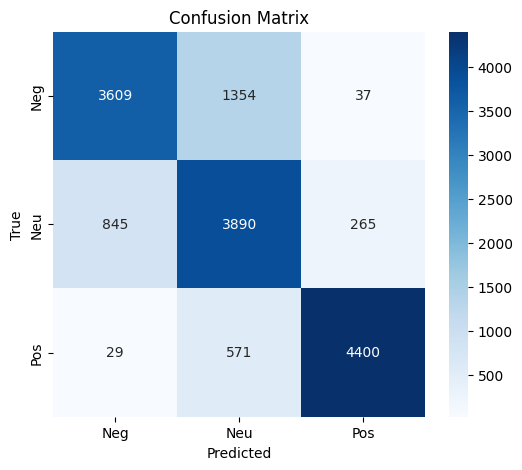

Saved report: /content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/versions/20260427_171438_distilbert-base-uncased_perclass100000_lr2e-05_ep3_maxlen256/classification_report.csv
Saved confusion matrix: /content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/versions/20260427_171438_distilbert-base-uncased_perclass100000_lr2e-05_ep3_maxlen256/confusion_matrix.csv
Saved confusion matrix image: /content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/versions/20260427_171438_distilbert-base-uncased_perclass100000_lr2e-05_ep3_maxlen256/confusion_matrix.png


In [ ]:
pred_output = trainer.predict(tokenized_datasets["test"])

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["negative", "neutral", "positive"],
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_path = f"{RUN_DIR}/classification_report.csv"
report_df.to_csv(report_path)

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["true_negative", "true_neutral", "true_positive"],
    columns=["pred_negative", "pred_neutral", "pred_positive"]
)
cm_path = f"{RUN_DIR}/confusion_matrix.csv"
cm_df.to_csv(cm_path)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    xticklabels=["Neg", "Neu", "Pos"],
    yticklabels=["Neg", "Neu", "Pos"],
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
cm_img_path = f"{RUN_DIR}/confusion_matrix.png"
plt.savefig(cm_img_path, bbox_inches="tight")
plt.show()

print("Saved report:", report_path)
print("Saved confusion matrix:", cm_path)
print("Saved confusion matrix image:", cm_img_path)

## 15. Save this run's model and configuration

This saves the current run's best checkpoint into the run folder.

In [ ]:
trainer.save_model(CURRENT_MODEL_DIR)
tokenizer.save_pretrained(CURRENT_MODEL_DIR)

run_info = {
    "run_id": RUN_ID,
    "run_name": RUN_NAME,
    "run_dir": RUN_DIR,
    "current_model_dir": CURRENT_MODEL_DIR,
    "source_type": "base_model",
    "base_model_name": BASE_MODEL_NAME,
    "max_per_class_train": MAX_PER_CLASS_TRAIN,
    "actual_train_rows": int(len(train_df)),
    "validation_rows": int(len(val_df)),
    "test_rows": int(len(test_df)),
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "weight_decay": WEIGHT_DECAY,
    "use_early_stopping": USE_EARLY_STOPPING,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_threshold": EARLY_STOPPING_THRESHOLD,
    "validation_results": validation_results,
    "test_results": test_results,
    "created_at": datetime.now().isoformat()
}

save_json(f"{RUN_DIR}/run_config_and_metrics.json", run_info)

print("Saved current run model:")
print(CURRENT_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved current run model:
/content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/versions/20260427_171438_distilbert-base-uncased_perclass100000_lr2e-05_ep3_maxlen256/final_model


## 16. Compare with the best base-model experiment

This compares the current run's validation F1 with the saved best validation F1.

If the current run is better, it updates:

`01_BaseModel_Experiments/best_model/`

In [ ]:
current_f1 = validation_results["eval_f1_macro"]

if REEVALUATE_EXISTING_BEST and model_folder_exists(BEST_MODEL_DIR):
    print("Re-evaluating existing best model on the fixed validation set...")
    best_eval_results = evaluate_saved_model(
        BEST_MODEL_DIR,
        tokenized_datasets["validation"],
        tokenizer,
        training_args,
        data_collator,
        compute_metrics
    )

    if os.path.exists(BEST_METRICS_PATH):
        best_info = load_json(BEST_METRICS_PATH)
    else:
        best_info = {}

    best_info["validation_f1_macro"] = float(best_eval_results["eval_f1_macro"])
    best_info["validation_metrics"] = best_eval_results
    save_json(BEST_METRICS_PATH, best_info)

is_new_best = update_best_model_if_needed(
    current_f1=current_f1,
    current_metrics=validation_results,
    trainer=trainer,
    tokenizer=tokenizer,
    run_info=run_info
)

log_row = {
    "run_id": RUN_ID,
    "run_name": RUN_NAME,
    "source_type": "base_model",
    "base_model_name": BASE_MODEL_NAME,
    "max_per_class_train": MAX_PER_CLASS_TRAIN,
    "actual_train_rows": len(train_df),
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "use_early_stopping": USE_EARLY_STOPPING,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "validation_f1_macro": validation_results["eval_f1_macro"],
    "validation_accuracy": validation_results["eval_accuracy"],
    "test_f1_macro": test_results["eval_f1_macro"],
    "test_accuracy": test_results["eval_accuracy"],
    "is_new_best": is_new_best,
    "run_dir": RUN_DIR,
    "current_model_dir": CURRENT_MODEL_DIR,
    "created_at": datetime.now().isoformat()
}

append_experiment_log(LOG_PATH, log_row)

print("Experiment log saved:")
print(LOG_PATH)

pd.read_csv(LOG_PATH).tail()

Previous best validation F1: None
Current validation F1: 0.8003194916573556


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New best model saved:
/content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/best_model
Experiment log saved:
/content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/experiments_log.csv


,run_id,run_name,source_type,base_model_name,max_per_class_train,actual_train_rows,max_length,learning_rate,num_train_epochs,train_batch_size,...,use_early_stopping,early_stopping_patience,validation_f1_macro,validation_accuracy,test_f1_macro,test_accuracy,is_new_best,run_dir,current_model_dir,created_at
0,20260427_171438,20260427_171438_distilbert-base-uncased_percla...,base_model,distilbert-base-uncased,100000,300000,256,0.00002,3,16,...,True,1,0.800319,0.797467,0.795851,0.793267,True,/content/drive/MyDrive/DataMining_Project/01_B...,/content/drive/MyDrive/DataMining_Project/01_B...,2026-04-27T18:12:51.363454


## 17. Test the best model

This loads the current best base-model experiment and tests it on example reviews.

In [ ]:
best_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)
best_model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR)

device = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    "text-classification",
    model=best_model,
    tokenizer=best_tokenizer,
    device=device
)

texts = [
    "The jacket fits perfectly and the quality is excellent.",
    "The shoes are uncomfortable and broke after two days.",
    "The shirt is okay, nothing special."
]

predictions = sentiment_pipeline(texts, truncation=True, max_length=MAX_LENGTH)

for text, pred in zip(texts, predictions):
    print(text)
    print(pred)
    print()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

The jacket fits perfectly and the quality is excellent.
{'label': 'positive', 'score': 0.9881691932678223}

The shoes are uncomfortable and broke after two days.
{'label': 'negative', 'score': 0.8952210545539856}

The shirt is okay, nothing special.
{'label': 'neutral', 'score': 0.9227551221847534}



## 18. Optional: export test-set sentiment results as CSV

This creates a CSV containing the true sentiment, predicted sentiment, confidence score, and class probabilities.

In [ ]:
from scipy.special import softmax

probs = softmax(logits, axis=1)
confidence = np.max(probs, axis=1)

results_df = test_df.reset_index(drop=True).copy()
results_df["true_label"] = y_true
results_df["true_sentiment"] = [id2label[int(x)] for x in y_true]
results_df["predicted_label"] = y_pred
results_df["predicted_sentiment"] = [id2label[int(x)] for x in y_pred]
results_df["confidence"] = confidence
results_df["negative_probability"] = probs[:, 0]
results_df["neutral_probability"] = probs[:, 1]
results_df["positive_probability"] = probs[:, 2]

sentiment_csv_path = f"{RUN_DIR}/sentiment_results_test.csv"
results_df[
    [
        "rating",
        "bert_input",
        "true_sentiment",
        "predicted_sentiment",
        "confidence",
        "negative_probability",
        "neutral_probability",
        "positive_probability"
    ]
].to_csv(sentiment_csv_path, index=False)

print("Saved sentiment results:")
print(sentiment_csv_path)

Saved sentiment results:
/content/drive/MyDrive/DataMining_Project/01_BaseModel_Experiments/versions/20260427_171438_distilbert-base-uncased_perclass100000_lr2e-05_ep3_maxlen256/sentiment_results_test.csv
